# 🌡️ Modelo Híbrido de Serie Temporal Climática
### Estrategia: Tendencia + Estacionalidad Explícita + ARIMA sobre Residuo Puro

**Por qué SARIMA solo falla:**
- El operador estacional `(P,D,Q)_12` diferencia la serie y promedia la forma de la curva anual, lo que hace que las predicciones a largo plazo converjan a la media y se aplanen.
- Si en los residuos aún se ven patrones, es porque hay componentes que el modelo no está capturando (tendencia climática, amplitud estacional variable).

**Solución: Modelo Híbrido en 3 capas**
1. **Tendencia**: Regresión lineal sobre el tiempo → captura el calentamiento global
2. **Estacionalidad**: Dummies mensuales (coeficientes por mes) → preserva la curva anual completa sin aplanarla
3. **Residuo**: ARIMA solo sobre el ruido puro → ya estacionario, sin patrones, predecible

In [1]:
# ============================================================
# CELDA 1 — Imports y configuración global
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import joblib

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima.arima import auto_arima
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
from joblib import Parallel, delayed
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

MODEL_DIR = 'modelos_hibridos_v2'
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ Imports OK')
print(f'📁 Modelos se guardarán en: {MODEL_DIR}/')

✅ Imports OK
📁 Modelos se guardarán en: modelos_hibridos_v2/


In [2]:
# ============================================================
# CELDA 2 — Carga, agregación y exploración inicial
# ============================================================
df_raw = pd.read_csv('../data/tiempoDS.csv.gz')

# ✅ FIX: agregar ciudades → país (media simple por country/year/month)
df = (
    df_raw
    .groupby(['country', 'year', 'month'], as_index=False)['AvTemp']
    .mean()
)

print(f'Filas originales (ciudad×fecha): {len(df_raw):,}')
print(f'Filas tras agregación (país×fecha): {len(df):,}')
print(f'Países únicos: {df["country"].nunique()}')

print(f'\n=== CALIDAD DE DATOS ===')
print(f'Nulos en AvTemp: {df["AvTemp"].isnull().sum()}')

print(f'\n=== COBERTURA TEMPORAL ===')
print(f'Años: {df["year"].min()} – {df["year"].max()}')

display(df.head(10))
display(df['AvTemp'].describe().round(3))

Filas originales (ciudad×fecha): 7,699,159
Filas tras agregación (país×fecha): 343,169
Países únicos: 158

=== CALIDAD DE DATOS ===
Nulos en AvTemp: 0

=== COBERTURA TEMPORAL ===
Años: 1819 – 2012


,country,year,month,AvTemp
0,Afghanistan,1833,1,1.1450
1,Afghanistan,1833,2,2.1684
2,Afghanistan,1833,3,6.5162
3,Afghanistan,1833,4,12.8322
4,Afghanistan,1833,5,18.5448
5,Afghanistan,1833,6,23.7564
6,Afghanistan,1833,7,25.0498
7,Afghanistan,1833,8,23.4082
8,Afghanistan,1833,9,18.8514
9,Afghanistan,1833,10,12.8946


count    343169.000
mean         18.083
std           9.522
min         -31.986
25%          12.564
50%          20.913
75%          25.478
max          37.812
Name: AvTemp, dtype: float64

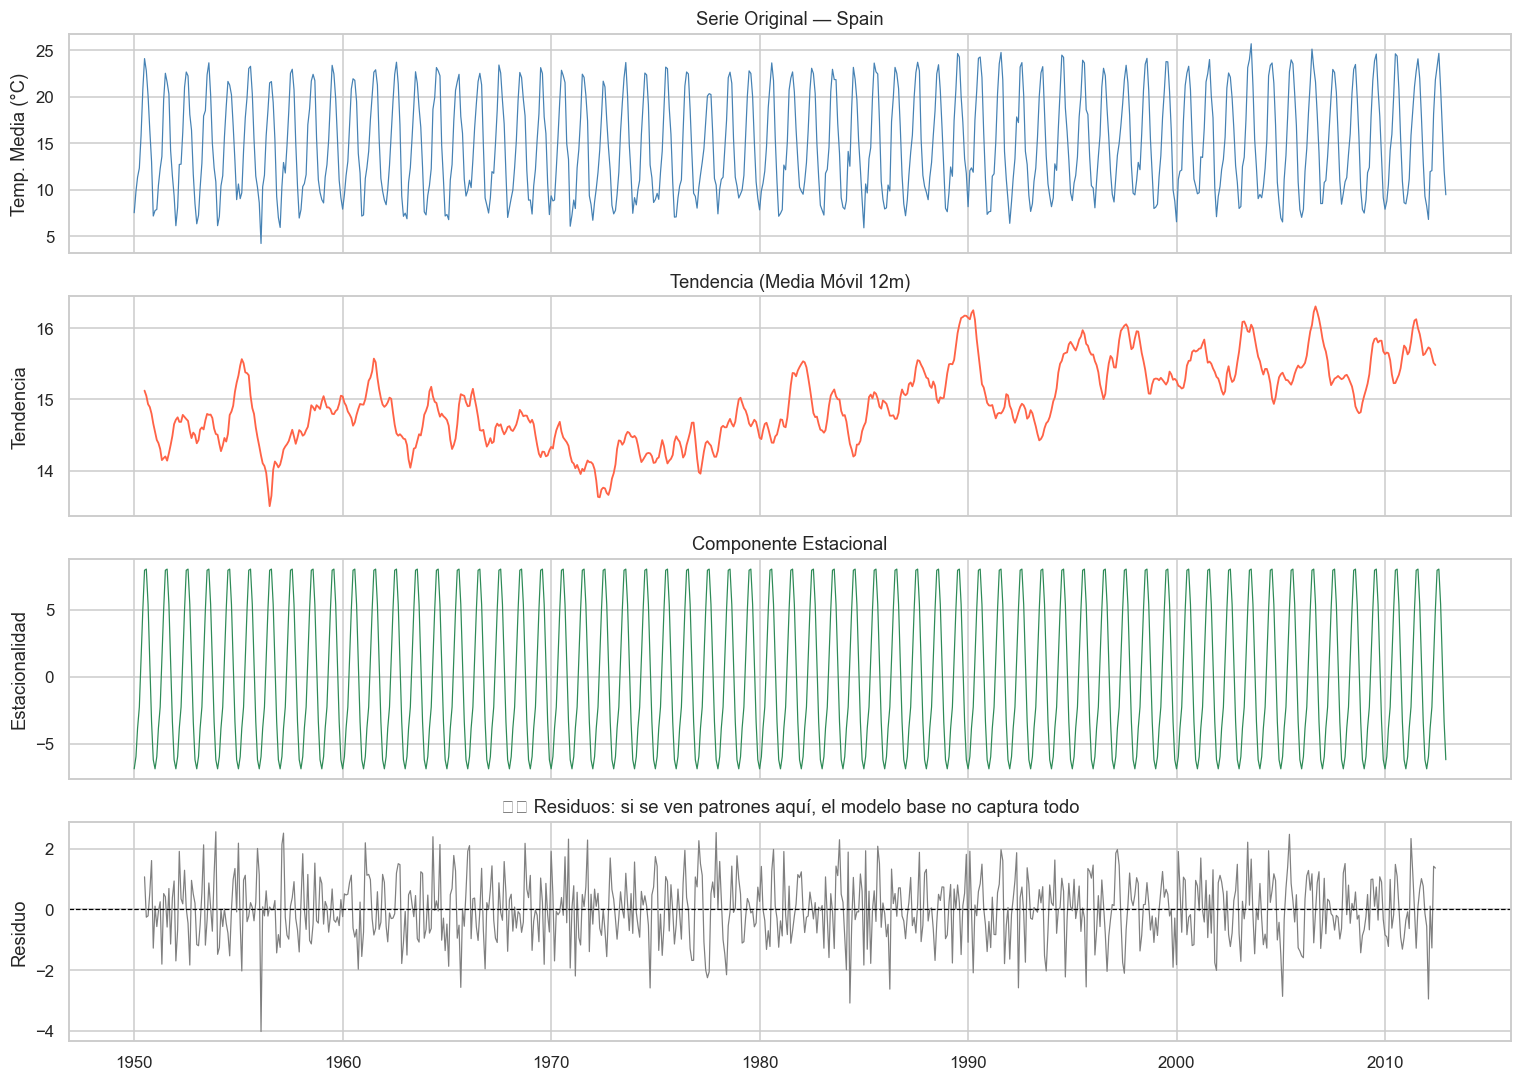


=== ADF Test sobre residuos de descomposición clásica ===
p-value: 0.000000 → ✅ Estacionario
Std de residuos: 1.034 °C  (ideal: < 1.5 para clima mensual)


In [3]:
# ============================================================
# CELDA 3 — Exploración visual de un país de referencia
# Analiza la señal antes de modelar: tendencia, estacionalidad, ruido
# ============================================================
PAIS_REF = 'Spain'

df_ref = df[df['country'] == PAIS_REF].copy()
df_ref['date'] = pd.to_datetime(df_ref[['year', 'month']].assign(day=1))
df_ref.set_index('date', inplace=True)
df_ref.sort_index(inplace=True)
df_ref = df_ref[df_ref.index >= '1950-01-01']

# ✅ FIX: eliminar duplicados ANTES de asfreq
df_ref = df_ref[~df_ref.index.duplicated(keep='first')]

# Ahora reindexar al rango completo e interpolar huecos
full_range = pd.date_range(start=df_ref.index.min(), end=df_ref.index.max(), freq='MS')
series = df_ref['AvTemp'].reindex(full_range).interpolate(method='linear')
series.index.name = 'date'

# --- Descomposición clásica (solo diagnóstico visual, NO se usa para modelar) ---
decomp = seasonal_decompose(series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(series, lw=0.8, color='steelblue')
axes[0].set_ylabel('Temp. Media (°C)')
axes[0].set_title(f'Serie Original — {PAIS_REF}')

axes[1].plot(decomp.trend, lw=1.2, color='tomato')
axes[1].set_ylabel('Tendencia')
axes[1].set_title('Tendencia (Media Móvil 12m)')

axes[2].plot(decomp.seasonal, lw=0.8, color='seagreen')
axes[2].set_ylabel('Estacionalidad')
axes[2].set_title('Componente Estacional')

axes[3].plot(decomp.resid, lw=0.8, color='grey')
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_ylabel('Residuo')
axes[3].set_title('⚠️ Residuos: si se ven patrones aquí, el modelo base no captura todo')

plt.tight_layout()
plt.show()

# Test de estacionariedad sobre residuos
resid_clean = decomp.resid.dropna()
adf = adfuller(resid_clean)
print(f'\n=== ADF Test sobre residuos de descomposición clásica ===')
print(f'p-value: {adf[1]:.6f} → {"✅ Estacionario" if adf[1] < 0.05 else "❌ No estacionario (problemas!)"}')
print(f'Std de residuos: {resid_clean.std():.3f} °C  (ideal: < 1.5 para clima mensual)')

Entrenando SARIMA estándar para diagnóstico (puede tardar ~30s)...


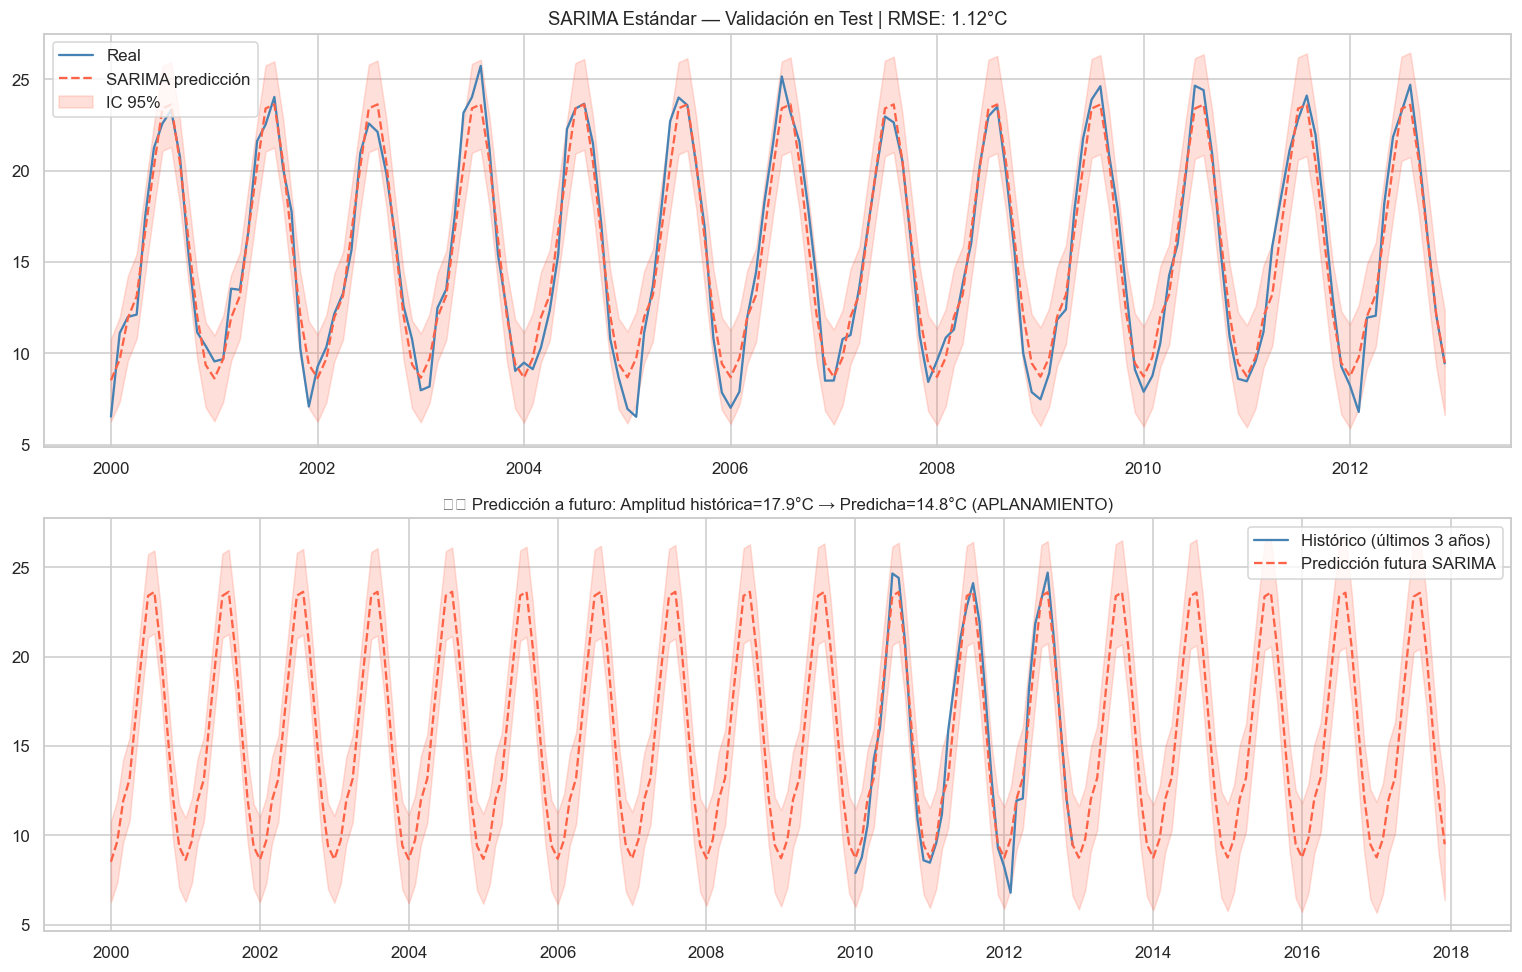


=== DIAGNÓSTICO DEL APLANAMIENTO ===
Amplitud estacional histórica (últimos 2 años): 17.89°C
Amplitud estacional predicha (último año predicho): 14.79°C
Pérdida de amplitud: 17.3%

→ El operador (P,D,Q)_12 diferencia la serie y promedia la curva anual,
  haciendo que las predicciones converjan a la media estacional fija.


In [4]:
# ============================================================
# CELDA 4 — Diagnóstico de por qué SARIMA aplana predicciones
# Visualiza el problema antes de aplicar la solución
# ============================================================
from pmdarima.arima import auto_arima as _auto_arima

PAIS_DIAG = 'Spain'
df_diag = df[df['country'] == PAIS_DIAG].copy()
df_diag['date'] = pd.to_datetime(df_diag[['year', 'month']].assign(day=1))
df_diag.set_index('date', inplace=True)
df_diag.sort_index(inplace=True)
df_diag = df_diag[df_diag.index >= '1950-01-01']
series_diag = df_diag['AvTemp'].asfreq('MS').interpolate(method='linear')

train_diag = series_diag[series_diag.index < '2000-01-01']
test_diag = series_diag[series_diag.index >= '2000-01-01']

print('Entrenando SARIMA estándar para diagnóstico (puede tardar ~30s)...')
m_sarima = _auto_arima(train_diag, m=12, seasonal=True, stepwise=True,
                        suppress_warnings=True, error_action='ignore')
pred_sarima, ci_sarima = m_sarima.predict(n_periods=len(test_diag), return_conf_int=True)

# Predicción a futuro (5 años) para ver el aplanamiento
pred_future, ci_future = m_sarima.predict(n_periods=len(test_diag) + 60, return_conf_int=True)
future_dates = pd.date_range(start=test_diag.index[0], periods=len(test_diag)+60, freq='MS')

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Plot 1: Test period
axes[0].plot(test_diag.index, test_diag.values, label='Real', color='steelblue', lw=1.5)
axes[0].plot(test_diag.index, pred_sarima, label='SARIMA predicción', color='tomato', lw=1.5, ls='--')
axes[0].fill_between(test_diag.index, ci_sarima[:,0], ci_sarima[:,1], alpha=0.2, color='tomato', label='IC 95%')
rmse_sarima = np.sqrt(mean_squared_error(test_diag.values, pred_sarima))
axes[0].set_title(f'SARIMA Estándar — Validación en Test | RMSE: {rmse_sarima:.2f}°C', fontsize=12)
axes[0].legend()

# Plot 2: Predicción futura (se aprecia el aplanamiento)
axes[1].plot(series_diag[-36:].index, series_diag[-36:].values, label='Histórico (últimos 3 años)', color='steelblue', lw=1.5)
axes[1].plot(future_dates, pred_future, label='Predicción futura SARIMA', color='tomato', lw=1.5, ls='--')
axes[1].fill_between(future_dates, ci_future[:,0], ci_future[:,1], alpha=0.2, color='tomato')
amplitude_hist = series_diag[-24:].max() - series_diag[-24:].min()
amplitude_pred = max(pred_future[-12:]) - min(pred_future[-12:])
axes[1].set_title(f'⚠️ Predicción a futuro: Amplitud histórica={amplitude_hist:.1f}°C → Predicha={amplitude_pred:.1f}°C (APLANAMIENTO)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n=== DIAGNÓSTICO DEL APLANAMIENTO ===')
print(f'Amplitud estacional histórica (últimos 2 años): {amplitude_hist:.2f}°C')
print(f'Amplitud estacional predicha (último año predicho): {amplitude_pred:.2f}°C')
print(f'Pérdida de amplitud: {((amplitude_hist - amplitude_pred)/amplitude_hist*100):.1f}%')
print(f'\n→ El operador (P,D,Q)_12 diferencia la serie y promedia la curva anual,')
print(f'  haciendo que las predicciones converjan a la media estacional fija.')

In [5]:
# ============================================================
# CELDA 5 — Funciones del modelo híbrido mejorado
# ============================================================

def fit_trend_seasonal(series):
    """
    Ajusta tendencia lineal + dummies mensuales de forma explícita.
    Retorna los parámetros y la serie de residuos puros.
    """
    t = np.arange(len(series))
    months = series.index.month
    
    # Matriz de diseño: tendencia + 11 dummies mensuales (evitamos colinealidad)
    X = np.column_stack([
        t,
        *[( months == m ).astype(int) for m in range(1, 12)]  # enero=ref
    ])
    
    reg = LinearRegression().fit(X, series.values)
    fitted = reg.predict(X)
    residuals = series.values - fitted
    
    return reg, residuals


def predict_trend_seasonal(reg, n_periods, last_index):
    """
    Genera predicciones de la componente determinista (tendencia + estacionalidad)
    para los próximos n_periods pasos.
    """
    t_start = last_index + 1
    t_future = np.arange(t_start, t_start + n_periods)
    future_dates = pd.date_range(
        start=pd.Timestamp('1950-01-01') + pd.DateOffset(months=t_start),
        periods=n_periods, freq='MS'
    )
    months_future = future_dates.month
    
    X_future = np.column_stack([
        t_future,
        *[(months_future == m).astype(int) for m in range(1, 12)]
    ])
    
    return reg.predict(X_future), future_dates


def diagnostics_residuals(residuals, country_name=''):
    """
    Diagnóstico completo de los residuos: ADF, Ljung-Box, normalidad, ACF/PACF.
    Retorna un dict con todos los estadísticos.
    """
    r = np.array(residuals)
    r_clean = r[~np.isnan(r)]
    
    adf_stat, adf_pval, *_ = adfuller(r_clean)
    lb = acorr_ljungbox(r_clean, lags=[12, 24], return_df=True)
    _, norm_pval = stats.normaltest(r_clean)
    
    return {
        'n': len(r_clean),
        'mean': r_clean.mean(),
        'std': r_clean.std(),
        'adf_stat': adf_stat,
        'adf_pval': adf_pval,
        'is_stationary': adf_pval < 0.05,
        'lb_pval_12': lb['lb_pvalue'].iloc[0],
        'lb_pval_24': lb['lb_pvalue'].iloc[1],
        'no_autocorr_12': lb['lb_pvalue'].iloc[0] > 0.05,
        'norm_pval': norm_pval,
        'is_normal': norm_pval > 0.05
    }


print('✅ Funciones del modelo híbrido definidas')

✅ Funciones del modelo híbrido definidas


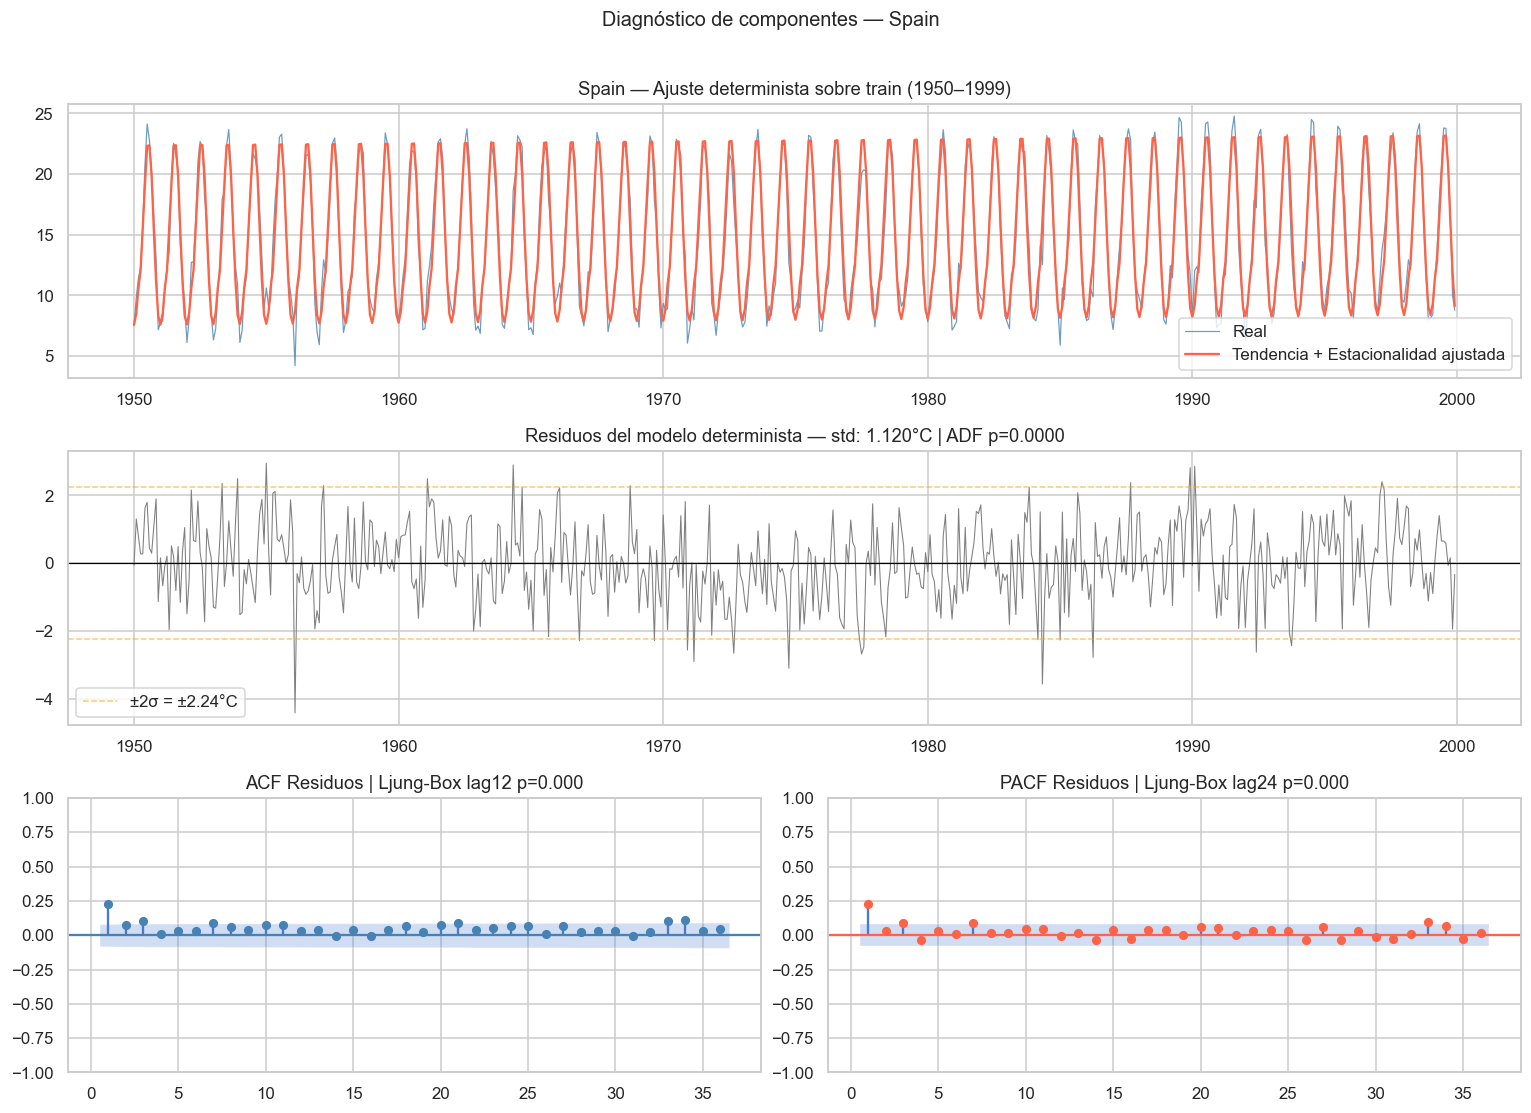

=== DIAGNÓSTICO DE RESIDUOS ===
Media residuos:            0.0000°C  (ideal: ~0)
Std residuos:              1.120°C
ADF p-value:               0.000000 → ✅ Estacionario
Ljung-Box lag=12:          p=0.0000 → ⚠️  Autocorrelación residual
Ljung-Box lag=24:          p=0.0000
Normalidad (D'Agostino):  p=0.2529 → ✅ Normal

→ Si Ljung-Box < 0.05: los residuos aún tienen autocorrelación → ARIMA sobre residuos ayudará mucho
→ Si Ljung-Box > 0.05: la descomposición ya captura todo; ARIMA sobre residuos aportará poco


In [6]:
# ============================================================
# CELDA 6 — Análisis detallado en un país (antes de entrenar todo)
# Inspecciona la calidad de la separación de componentes
# ============================================================
PAIS_ANALISIS = 'Spain'

df_a = df[df['country'] == PAIS_ANALISIS].copy()
df_a['date'] = pd.to_datetime(df_a[['year', 'month']].assign(day=1))
df_a.set_index('date', inplace=True)
df_a.sort_index(inplace=True)
df_a = df_a[df_a.index >= '1950-01-01']
series_a = df_a['AvTemp'].asfreq('MS').interpolate(method='linear')

train_a = series_a[series_a.index < '2000-01-01']

# Ajustar tendencia + estacionalidad sobre train
reg_a, resid_a = fit_trend_seasonal(train_a)
diag_a = diagnostics_residuals(resid_a, PAIS_ANALISIS)

# --- Gráfica de diagnóstico de residuos ---
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 2, figure=fig)

# 1. Fitted vs Real
ax1 = fig.add_subplot(gs[0, :])
t_train = np.arange(len(train_a))
months_tr = train_a.index.month
X_tr = np.column_stack([t_train, *[(months_tr == m).astype(int) for m in range(1,12)]])
fitted_tr = reg_a.predict(X_tr)
ax1.plot(train_a.index, train_a.values, label='Real', color='steelblue', lw=0.8, alpha=0.8)
ax1.plot(train_a.index, fitted_tr, label='Tendencia + Estacionalidad ajustada', color='tomato', lw=1.5)
ax1.set_title(f'{PAIS_ANALISIS} — Ajuste determinista sobre train (1950–1999)')
ax1.legend()

# 2. Residuos en tiempo
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(train_a.index, resid_a, color='gray', lw=0.7)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(2*diag_a['std'], color='orange', lw=1, ls='--', alpha=0.6, label=f'±2σ = ±{2*diag_a["std"]:.2f}°C')
ax2.axhline(-2*diag_a['std'], color='orange', lw=1, ls='--', alpha=0.6)
ax2.set_title(f'Residuos del modelo determinista — std: {diag_a["std"]:.3f}°C | ADF p={diag_a["adf_pval"]:.4f}')
ax2.legend()

# 3. ACF de residuos
ax3 = fig.add_subplot(gs[2, 0])
plot_acf(resid_a, lags=36, ax=ax3, color='steelblue', zero=False)
ax3.set_title(f'ACF Residuos | Ljung-Box lag12 p={diag_a["lb_pval_12"]:.3f}')

# 4. PACF de residuos
ax4 = fig.add_subplot(gs[2, 1])
plot_pacf(resid_a, lags=36, ax=ax4, color='tomato', zero=False)
ax4.set_title(f'PACF Residuos | Ljung-Box lag24 p={diag_a["lb_pval_24"]:.3f}')

plt.suptitle(f'Diagnóstico de componentes — {PAIS_ANALISIS}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('=== DIAGNÓSTICO DE RESIDUOS ===')
print(f'Media residuos:            {diag_a["mean"]:.4f}°C  (ideal: ~0)')
print(f'Std residuos:              {diag_a["std"]:.3f}°C')
print(f'ADF p-value:               {diag_a["adf_pval"]:.6f} → {"✅ Estacionario" if diag_a["is_stationary"] else "❌ No estacionario"}')
print(f'Ljung-Box lag=12:          p={diag_a["lb_pval_12"]:.4f} → {"✅ Sin autocorrelación" if diag_a["no_autocorr_12"] else "⚠️  Autocorrelación residual"}')
print(f'Ljung-Box lag=24:          p={diag_a["lb_pval_24"]:.4f}')
print(f'Normalidad (D\'Agostino):  p={diag_a["norm_pval"]:.4f} → {"✅ Normal" if diag_a["is_normal"] else "ℹ️  No normal (habitual en clima)"}')
print()
print('→ Si Ljung-Box < 0.05: los residuos aún tienen autocorrelación → ARIMA sobre residuos ayudará mucho')
print('→ Si Ljung-Box > 0.05: la descomposición ya captura todo; ARIMA sobre residuos aportará poco')

In [7]:
# ============================================================
# CELDA 7 — Función autocontenida (sin dependencias externas)
# ============================================================
from pmdarima.arima import auto_arima
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np, pandas as pd, joblib, os

def train_hybrid_model(country_name, df_country):
    try:
        # --- Preparación ---
        df_c = df_country.copy()
        df_c['date'] = pd.to_datetime(df_c[['year', 'month']].assign(day=1))
        df_c.set_index('date', inplace=True)
        df_c.sort_index(inplace=True)
        df_c = df_c[df_c.index >= '1950-01-01']
        if len(df_c) < 60: return None
        df_c = df_c[~df_c.index.duplicated(keep='first')]
        full_range = pd.date_range(start=df_c.index.min(), end=df_c.index.max(), freq='MS')
        df_c = df_c.reindex(full_range)
        df_c['AvTemp'] = df_c['AvTemp'].interpolate(method='linear', limit_area='inside')
        df_c.dropna(subset=['AvTemp'], inplace=True)
        if len(df_c) < 60: return None

        # ✅ FIX 1: definir series desde df_c, no desde variable externa
        series = df_c['AvTemp']

        # --- Split dinámico (evita países sin datos antes de 2000) ---
        CUT = pd.Timestamp('2000-01-01')
        if series.index.min() >= CUT:
            # País sin datos antes de 2000: usar 80/20
            n_test  = max(12, int(len(series) * 0.2))
            train   = series.iloc[:-n_test]
            test    = series.iloc[-n_test:]
        else:
            train = series[series.index < CUT]
            test  = series[series.index >= CUT]

        if len(train) < 36 or len(test) < 12: return None

        # --- Tendencia + dummies mensuales sobre TRAIN ---
        t_tr = np.arange(len(train))
        m_tr = train.index.month
        X_tr = np.column_stack([t_tr, *[(m_tr == m).astype(int) for m in range(1, 12)]])
        reg = LinearRegression().fit(X_tr, train.values)
        resid_train = train.values - reg.predict(X_tr)

        # --- ARIMA sobre residuo puro ---
        model_arima = auto_arima(
            resid_train,
            m=1, seasonal=False,
            max_p=3, max_q=3, max_d=2,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            information_criterion='aic'
        )

        # --- Predicción en TEST ---
        t_te = np.arange(len(train), len(train) + len(test))
        m_te = test.index.month
        X_te = np.column_stack([t_te, *[(m_te == m).astype(int) for m in range(1, 12)]])
        pred_det   = reg.predict(X_te)
        pred_arima, ci_arima = model_arima.predict(n_periods=len(test), return_conf_int=True)
        pred_final = pred_det + pred_arima

        # --- Métricas ---
        rmse     = np.sqrt(mean_squared_error(test.values, pred_final))
        mae      = mean_absolute_error(test.values, pred_final)
        corr     = np.corrcoef(test.values, pred_final)[0, 1]
        amp_real = test.values.max() - test.values.min()
        amp_pred = pred_final.max() - pred_final.min()

        # --- Diagnóstico residuos ---
        adf_pval  = adfuller(resid_train)[1]
        lb12_pval = acorr_ljungbox(resid_train, lags=[12], return_df=True)['lb_pvalue'].iloc[0]

        # --- Guardar ---
        safe = country_name.replace(' ', '_').replace('/', '_')
        path = os.path.join(MODEL_DIR, f'{safe}.joblib')
        joblib.dump({
            'country':      country_name,
            'reg':          reg,
            'model_arima':  model_arima,
            'arima_order':  model_arima.order,
            'n_train':      len(train),
            # ✅ FIX 2: usar series (ya definida) en lugar de variable externa
            'series_start': series.index[0],
            'series_end':   series.index[-1],
            'test_dates':   test.index.tolist(),
            'test_real':    test.values.tolist(),
            'test_pred':    pred_final.tolist(),
            'ci_lower':     (pred_det + ci_arima[:, 0]).tolist(),
            'ci_upper':     (pred_det + ci_arima[:, 1]).tolist(),
            'rmse':         rmse,
            'mae':          mae,
            'corr':         corr,
            'amp_ratio':    amp_pred / amp_real,
            'resid_std':    resid_train.std(),
            'resid_adf_pval':  adf_pval,
            'resid_lb12_pval': lb12_pval,
        }, path)

        return {
            'Country': country_name, 'RMSE': rmse, 'MAE': mae,
            'Corr': corr, 'AmpRatio': amp_pred / amp_real,
            'ARIMA_Order': str(model_arima.order),
            'Resid_Std': resid_train.std(),
            'ADF_pval': adf_pval, 'LB12_pval': lb12_pval,
        }

    except Exception as e:
        print(f'❌ {country_name}: {e}')
        return None

print('✅ train_hybrid_model definida')

✅ train_hybrid_model definida


In [8]:
# ============================================================
# CELDA 8 — Entrenamiento en paralelo (versión corregida)
# ============================================================
print('🚀 Iniciando entrenamiento híbrido en paralelo...')

grouped = df.groupby('country')
total_countries = len(list(grouped.groups.keys()))

results = Parallel(n_jobs=-1, backend='loky', verbose=0)(
    delayed(train_hybrid_model)(name, group)
    for name, group in tqdm(grouped, total=total_countries, desc='Entrenando')
)

valid_results = [r for r in results if r is not None]

# ✅ FIX 1: diagnóstico si hay pocos resultados válidos
print(f'\nResultados válidos: {len(valid_results)} / {total_countries}')
if len(valid_results) == 0:
    print('❌ Ningún país produjo resultados. Ejecuta train_hybrid_model manualmente en un país para ver el error:')
    nombre_prueba = list(grouped.groups.keys())[0]
    resultado_prueba = train_hybrid_model(nombre_prueba, grouped.get_group(nombre_prueba))
    print(f'Resultado para {nombre_prueba}: {resultado_prueba}')
else:
    print(f'Ejemplo de resultado: {valid_results[0]}')

metrics_df = pd.DataFrame(valid_results)

# ✅ FIX 2: drop solo si la columna existe
metrics_df.drop(columns=[c for c in ['Path'] if c in metrics_df.columns], inplace=True)

metrics_df.to_csv('metricas_modelos_hibridos.csv', index=False)

print(f'\n✅ {len(valid_results)} / {total_countries} países entrenados')
print(f'\n=== RESUMEN GLOBAL ===')
if len(metrics_df) > 0:
    print(f'RMSE mediana:     {metrics_df["RMSE"].median():.3f}°C')
    print(f'MAE mediana:      {metrics_df["MAE"].median():.3f}°C')
    print(f'Correlación:      {metrics_df["Corr"].median():.4f}')
    print(f'AmpRatio mediana: {metrics_df["AmpRatio"].median():.3f}')
    display(metrics_df.head())

🚀 Iniciando entrenamiento híbrido en paralelo...


Entrenando: 100%|██████████| 158/158 [00:28<00:00,  5.51it/s]



Resultados válidos: 158 / 158
Ejemplo de resultado: {'Country': 'Afghanistan', 'RMSE': np.float64(1.4460714559971564), 'MAE': 1.0341067063014295, 'Corr': np.float64(0.9876283838612859), 'AmpRatio': np.float64(0.8203450414809823), 'ARIMA_Order': '(1, 0, 0)', 'Resid_Std': np.float64(1.2187635085179043), 'ADF_pval': np.float64(7.601736027625923e-12), 'LB12_pval': np.float64(1.8634206609896833e-07)}

✅ 158 / 158 países entrenados

=== RESUMEN GLOBAL ===
RMSE mediana:     0.868°C
MAE mediana:      0.683°C
Correlación:      0.9686
AmpRatio mediana: 0.756


,Country,RMSE,MAE,Corr,AmpRatio,ARIMA_Order,Resid_Std,ADF_pval,LB12_pval
0,Afghanistan,1.446071,1.034107,0.987628,0.820345,"(1, 0, 0)",1.218764,7.601736e-12,1.863421e-07
1,Albania,1.430812,1.149512,0.979434,0.737758,"(1, 0, 0)",1.218465,0.000000e+00,1.239824e-03
2,Algeria,1.226164,0.923627,0.987345,0.803325,"(1, 1, 1)",1.140588,0.000000e+00,6.921270e-10
3,Angola,0.667027,0.537649,0.901802,0.830104,"(2, 0, 0)",0.463993,3.043344e-17,5.523070e-75
4,Argentina,0.993159,0.764097,0.980838,0.784740,"(1, 0, 0)",1.009006,0.000000e+00,1.422656e-01


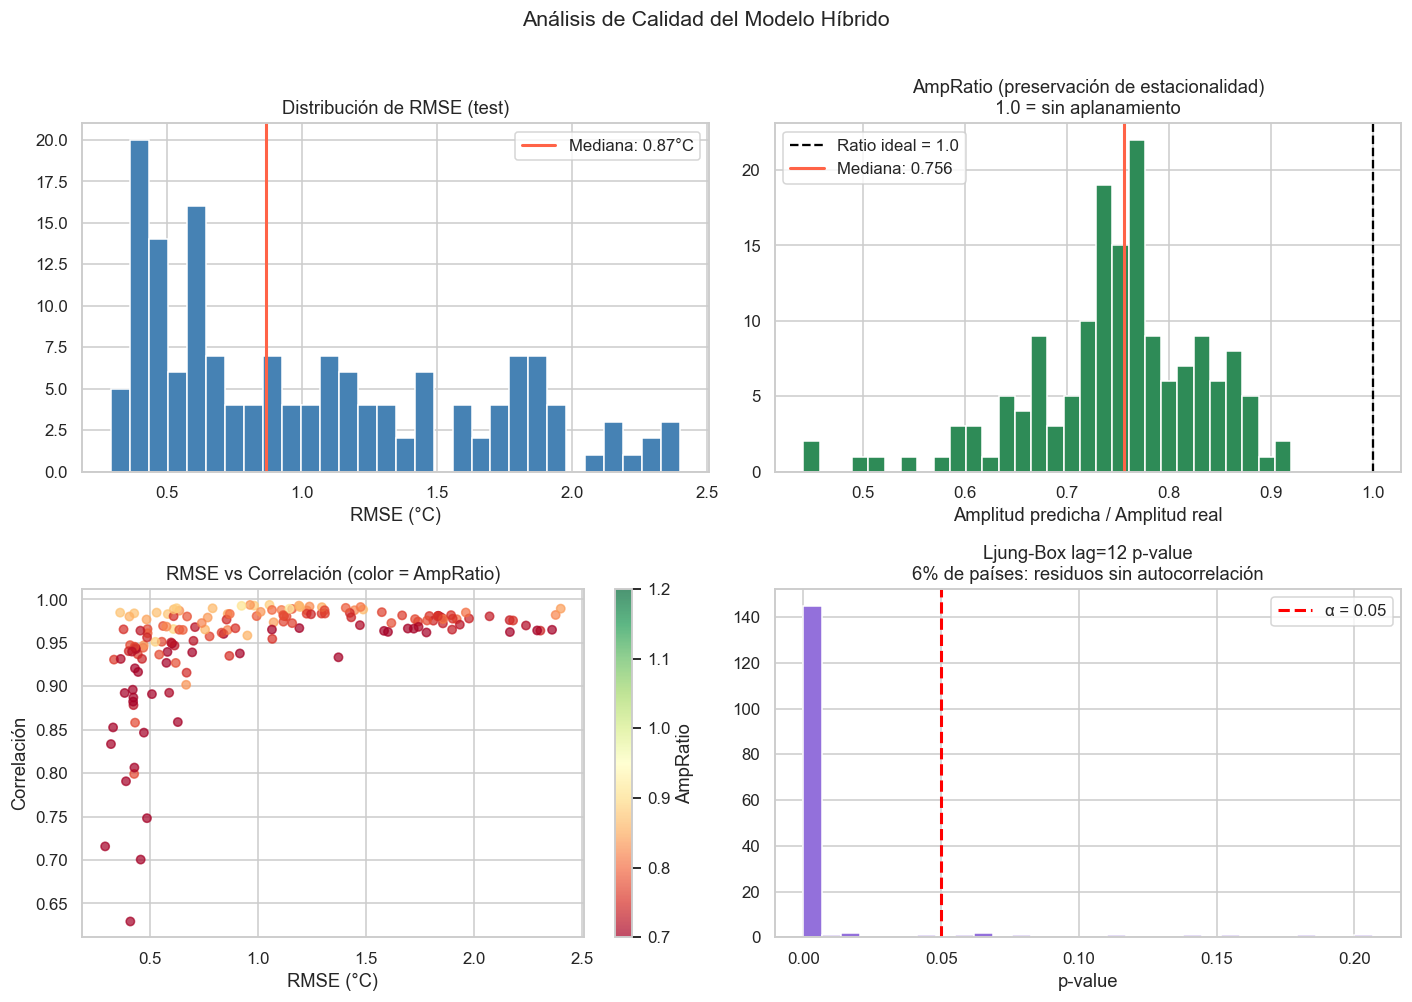

=== TOP 10 MEJORES MODELOS ===


,Country,RMSE,MAE,Corr,AmpRatio,ARIMA_Order
0,Indonesia,0.292271,0.229943,0.715689,0.575533,"(2, 0, 0)"
1,Malaysia,0.319195,0.251598,0.833495,0.618292,"(2, 0, 0)"
2,Singapore,0.328996,0.249101,0.852668,0.588162,"(2, 0, 2)"
3,Philippines,0.333280,0.257140,0.930773,0.757082,"(1, 0, 1)"
4,Madagascar,0.361697,0.289522,0.984871,0.870101,"(2, 0, 1)"
5,Sri Lanka,0.364328,0.284686,0.931543,0.708549,"(1, 0, 1)"
6,Ghana,0.377386,0.288781,0.965611,0.747178,"(1, 0, 1)"
7,Costa Rica,0.382562,0.293475,0.892342,0.604629,"(1, 0, 1)"
8,Congo,0.388758,0.308163,0.790682,0.665316,"(2, 0, 0)"
9,Liberia,0.401470,0.325178,0.940494,0.741053,"(1, 0, 1)"



=== TOP 10 PEORES MODELOS ===


,Country,RMSE,MAE,Corr,AmpRatio
0,Mongolia,2.400104,1.829768,0.989439,0.836798
1,Kazakhstan,2.376668,1.650267,0.982173,0.819980
2,Estonia,2.360046,1.786597,0.965115,0.668641
3,Finland,2.306010,1.777865,0.964113,0.740318
4,Latvia,2.291028,1.738382,0.964339,0.671631
5,Belarus,2.239389,1.697990,0.970035,0.712697
6,Ukraine,2.179695,1.662343,0.975791,0.749459
7,Lithuania,2.164965,1.639720,0.962532,0.677346
8,Moldova,2.163841,1.646492,0.976230,0.732643
9,Turkmenistan,2.070803,1.489037,0.980615,0.729803


In [9]:
# ============================================================
# CELDA 9 — Análisis estadístico de métricas globales
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Distribución de RMSE
axes[0,0].hist(metrics_df['RMSE'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].axvline(metrics_df['RMSE'].median(), color='tomato', lw=2, label=f'Mediana: {metrics_df["RMSE"].median():.2f}°C')
axes[0,0].set_title('Distribución de RMSE (test)')
axes[0,0].set_xlabel('RMSE (°C)')
axes[0,0].legend()

# 2. Distribución de AmpRatio
axes[0,1].hist(metrics_df['AmpRatio'].dropna(), bins=30, color='seagreen', edgecolor='white')
axes[0,1].axvline(1.0, color='black', lw=1.5, ls='--', label='Ratio ideal = 1.0')
axes[0,1].axvline(metrics_df['AmpRatio'].median(), color='tomato', lw=2, label=f'Mediana: {metrics_df["AmpRatio"].median():.3f}')
axes[0,1].set_title('AmpRatio (preservación de estacionalidad)\n1.0 = sin aplanamiento')
axes[0,1].set_xlabel('Amplitud predicha / Amplitud real')
axes[0,1].legend()

# 3. Scatter RMSE vs Correlación
sc = axes[1,0].scatter(metrics_df['RMSE'], metrics_df['Corr'], 
                        c=metrics_df['AmpRatio'], cmap='RdYlGn', vmin=0.7, vmax=1.2, alpha=0.7, s=30)
plt.colorbar(sc, ax=axes[1,0], label='AmpRatio')
axes[1,0].set_xlabel('RMSE (°C)')
axes[1,0].set_ylabel('Correlación')
axes[1,0].set_title('RMSE vs Correlación (color = AmpRatio)')

# 4. Ljung-Box p-value: ¿queda autocorrelación en residuos?
frac_ok = (metrics_df['LB12_pval'] > 0.05).mean()
axes[1,1].hist(metrics_df['LB12_pval'], bins=30, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(0.05, color='red', lw=2, ls='--', label='α = 0.05')
axes[1,1].set_title(f'Ljung-Box lag=12 p-value\n{frac_ok:.0%} de países: residuos sin autocorrelación')
axes[1,1].set_xlabel('p-value')
axes[1,1].legend()

plt.suptitle('Análisis de Calidad del Modelo Híbrido', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('=== TOP 10 MEJORES MODELOS ===')
display(metrics_df.sort_values('RMSE').head(10)[['Country','RMSE','MAE','Corr','AmpRatio','ARIMA_Order']].reset_index(drop=True))

print('\n=== TOP 10 PEORES MODELOS ===')
display(metrics_df.sort_values('RMSE', ascending=False).head(10)[['Country','RMSE','MAE','Corr','AmpRatio']].reset_index(drop=True))

In [18]:
# ============================================================
# CELDA A — Extraer tasa de calentamiento y aceleración por país
# ============================================================

# Tasa de calentamiento: coef_[0] del modelo = °C/mes → convertir a °C/década
# Aceleración: ajustar regresión cuadrática sobre la serie completa y comparar
# con la lineal → si el término cuadrático es positivo, el calentamiento se acelera

from scipy import stats

warming_records = []

for country_name in metrics_df['Country']:
    safe = country_name.replace(' ', '_').replace('/', '_')
    path = os.path.join(MODEL_DIR, f'{safe}.joblib')
    if not os.path.exists(path):
        continue

    data = joblib.load(path)
    reg  = data['reg']

    # --- Tasa lineal ---
    # reg.coef_[0] = °C/mes → × 120 = °C/década
    rate_per_decade = reg.coef_[0] * 120

    # --- Aceleración: reentrenar con término cuadrático sobre serie completa ---
    df_c = df[df['country'] == country_name].copy()
    df_c['date'] = pd.to_datetime(df_c[['year', 'month']].assign(day=1))
    df_c.set_index('date', inplace=True)
    df_c.sort_index(inplace=True)
    df_c = df_c[~df_c.index.duplicated(keep='first')]
    full_range = pd.date_range(start=df_c.index.min(), end=df_c.index.max(), freq='MS')
    df_c = df_c.reindex(full_range)
    df_c['AvTemp'] = df_c['AvTemp'].interpolate(method='linear', limit_area='inside')
    df_c.dropna(subset=['AvTemp'], inplace=True)
    series = df_c['AvTemp']

    t  = np.arange(len(series))
    t2 = t ** 2
    m  = series.index.month

    # Modelo cuadrático: tendencia² + dummies mensuales
    X_quad = np.column_stack([t, t2, *[(m == mo).astype(int) for mo in range(1, 12)]])
    reg_quad = LinearRegression().fit(X_quad, series.values)

    # coef_[1] = °C/mes² → × 120² = °C/década²  (aceleración)
    accel_per_decade2 = reg_quad.coef_[1] * (120 ** 2)

    # R² del modelo cuadrático vs lineal: ¿merece la pena el término extra?
    X_lin = np.column_stack([t, *[(m == mo).astype(int) for mo in range(1, 12)]])
    r2_lin  = LinearRegression().fit(X_lin,  series.values).score(X_lin,  series.values)
    r2_quad = reg_quad.score(X_quad, series.values)
    r2_gain = r2_quad - r2_lin   # ganancia de R² por añadir curvatura

    # Distancia al polo (media del país)
    Dist_to_Pole_mean = df_raw[df_raw['country'] == country_name]['Dist_to_Pole'].mean()

    warming_records.append({
        'Country':          country_name,
        'Rate_per_decade':  rate_per_decade,       # °C/década (positivo = calentamiento)
        'Accel_per_decade2': accel_per_decade2,    # °C/década² (positivo = aceleración)
        'R2_gain':          r2_gain,               # ganancia de R² del término cuadrático
        'Dist_to_Pole':        Dist_to_Pole_mean,
        'RMSE':             data['rmse'],
    })

warming_df = pd.DataFrame(warming_records)
warming_df.to_csv('warming_analysis.csv', index=False)

print(f'✅ Análisis de calentamiento completado: {len(warming_df)} países')
print(f'\n=== RESUMEN GLOBAL ===')
print(f'Tasa mediana:       {warming_df["Rate_per_decade"].median():.3f} °C/década')
print(f'Máxima:             {warming_df["Rate_per_decade"].max():.3f} °C/década  ({warming_df.loc[warming_df["Rate_per_decade"].idxmax(), "Country"]})')
print(f'Mínima:             {warming_df["Rate_per_decade"].min():.3f} °C/década  ({warming_df.loc[warming_df["Rate_per_decade"].idxmin(), "Country"]})')
print(f'\nAceleración mediana:  {warming_df["Accel_per_decade2"].median():.4f} °C/década²')
print(f'Países acelerando:    {(warming_df["Accel_per_decade2"] > 0).sum()} / {len(warming_df)}')
print(f'\n=== TOP 10 QUE MÁS SE CALIENTAN ===')
display(warming_df.sort_values('Rate_per_decade', ascending=False).head(10)[
    ['Country','Rate_per_decade','Accel_per_decade2','Dist_to_Pole']
].reset_index(drop=True))

✅ Análisis de calentamiento completado: 158 países

=== RESUMEN GLOBAL ===
Tasa mediana:       0.131 °C/década
Máxima:             0.348 °C/década  (Mongolia)
Mínima:             -0.031 °C/década  (Iceland)

Aceleración mediana:  0.0040 °C/década²
Países acelerando:    126 / 158

=== TOP 10 QUE MÁS SE CALIENTAN ===


,Country,Rate_per_decade,Accel_per_decade2,Dist_to_Pole
0,Mongolia,0.348174,0.008911,42.580000
1,Kazakhstan,0.280109,0.003312,41.026510
2,Turkmenistan,0.261020,-0.027890,50.616591
3,Uzbekistan,0.224991,0.003850,49.592342
4,Russia,0.211161,0.009170,36.234603
5,Tajikistan,0.209922,0.006948,49.815000
6,Afghanistan,0.206069,0.004638,55.819374
7,Mauritania,0.206029,-0.004606,71.520000
8,Estonia,0.192714,0.007076,31.340000
9,Latvia,0.192132,0.008119,33.750000


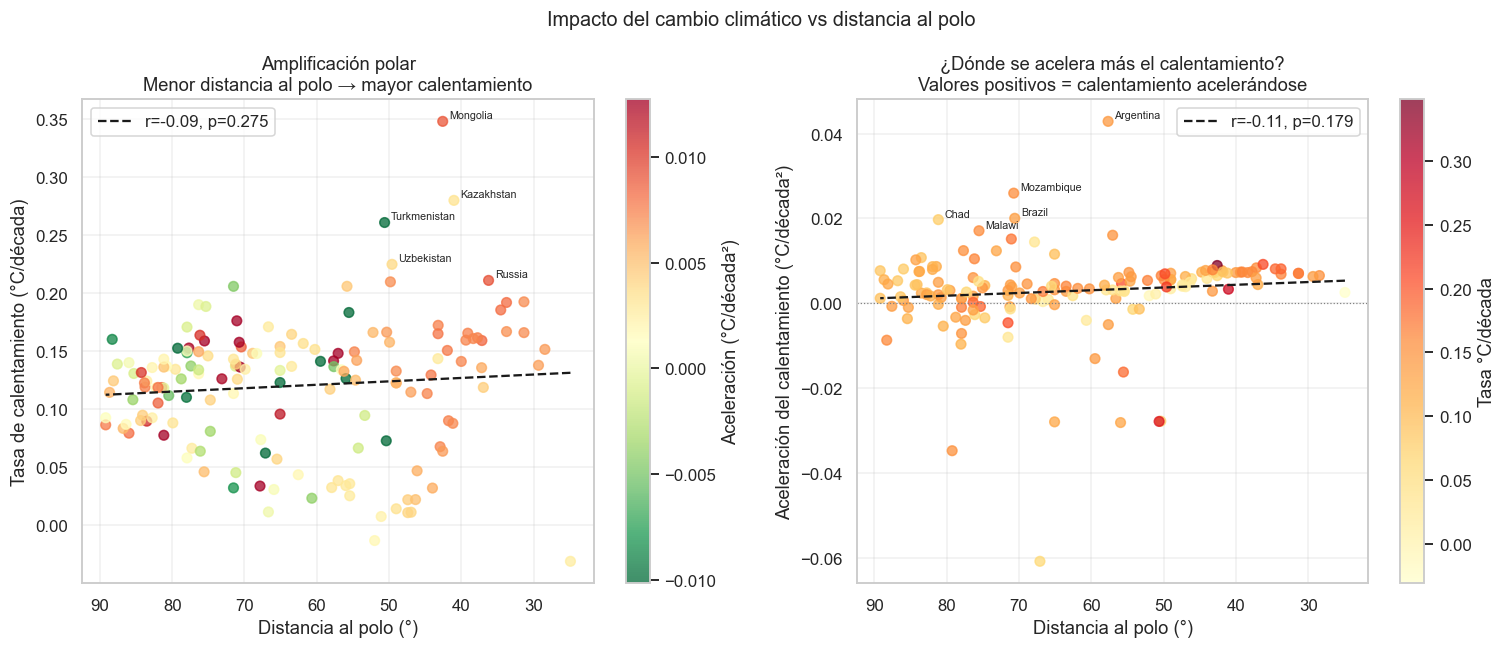

Correlación dist_polo ↔ tasa:        r=-0.087  (p=0.2746)
Correlación dist_polo ↔ aceleración: r=-0.108 (p=0.1787)

→ r negativo significa: más cerca del polo = mayor calentamiento (amplificación polar)


In [19]:
# ============================================================
# CELDA B — Relación distancia al polo vs calentamiento
# Amplificación polar: países más cercanos al polo se calientan más rápido
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Dist_to_Pole vs tasa de calentamiento ---
ax = axes[0]
sc = ax.scatter(
    warming_df['Dist_to_Pole'],
    warming_df['Rate_per_decade'],
    c=warming_df['Accel_per_decade2'],
    cmap='RdYlGn_r', s=40, alpha=0.75,
    vmin=warming_df['Accel_per_decade2'].quantile(0.05),
    vmax=warming_df['Accel_per_decade2'].quantile(0.95)
)
plt.colorbar(sc, ax=ax, label='Aceleración (°C/década²)')

# Línea de tendencia
mask = warming_df[['Dist_to_Pole','Rate_per_decade']].notna().all(axis=1)
slope, intercept, r, p, _ = stats.linregress(
    warming_df.loc[mask, 'Dist_to_Pole'],
    warming_df.loc[mask, 'Rate_per_decade']
)
x_line = np.linspace(warming_df['Dist_to_Pole'].min(), warming_df['Dist_to_Pole'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.5,
        label=f'r={r:.2f}, p={p:.3f}')

# Etiquetar los 5 más extremos
top5 = warming_df.nlargest(5, 'Rate_per_decade')
for _, row in top5.iterrows():
    ax.annotate(row['Country'], (row['Dist_to_Pole'], row['Rate_per_decade']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Distancia al polo (°)')
ax.set_ylabel('Tasa de calentamiento (°C/década)')
ax.set_title('Amplificación polar\nMenor distancia al polo → mayor calentamiento')
ax.legend()
ax.grid(True, alpha=0.3)

# Invertir eje X: polo a la izquierda, ecuador a la derecha
ax.invert_xaxis()

# --- Panel 2: Dist_to_Pole vs aceleración ---
ax2 = axes[1]
sc2 = ax2.scatter(
    warming_df['Dist_to_Pole'],
    warming_df['Accel_per_decade2'],
    c=warming_df['Rate_per_decade'],
    cmap='YlOrRd', s=40, alpha=0.75
)
plt.colorbar(sc2, ax=ax2, label='Tasa °C/década')

slope2, intercept2, r2, p2, _ = stats.linregress(
    warming_df.loc[mask, 'Dist_to_Pole'],
    warming_df.loc[mask, 'Accel_per_decade2']
)
ax2.plot(x_line, slope2 * x_line + intercept2, 'k--', lw=1.5,
         label=f'r={r2:.2f}, p={p2:.3f}')
ax2.axhline(0, color='gray', lw=0.8, ls=':')

top5_acc = warming_df.nlargest(5, 'Accel_per_decade2')
for _, row in top5_acc.iterrows():
    ax2.annotate(row['Country'], (row['Dist_to_Pole'], row['Accel_per_decade2']),
                 fontsize=7, xytext=(4, 2), textcoords='offset points')

ax2.set_xlabel('Distancia al polo (°)')
ax2.set_ylabel('Aceleración del calentamiento (°C/década²)')
ax2.set_title('¿Dónde se acelera más el calentamiento?\nValores positivos = calentamiento acelerándose')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.suptitle('Impacto del cambio climático vs distancia al polo', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Correlación dist_polo ↔ tasa:        r={r:.3f}  (p={p:.4f})')
print(f'Correlación dist_polo ↔ aceleración: r={r2:.3f} (p={p2:.4f})')
print(f'\n→ r negativo significa: más cerca del polo = mayor calentamiento (amplificación polar)')

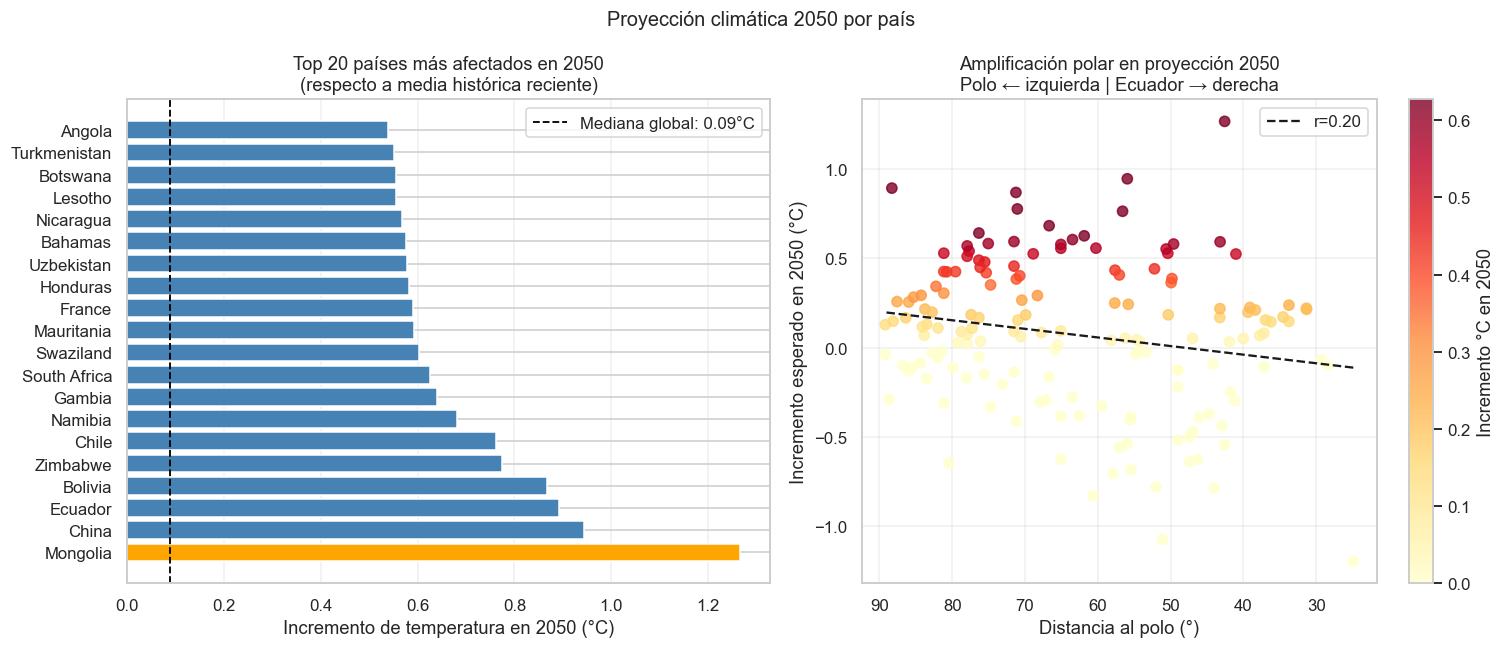

=== RESUMEN PROYECCIÓN 2050 ===
Incremento mediano global:  0.09°C
Incremento máximo:          1.26°C  (Mongolia)
Países con >2°C de subida:  0
Correlación polo↔incremento: r=0.197 (p=0.0131)

=== TOP 10 MÁS AFECTADOS EN 2050 ===


,Country,Temp_hist,Temp_2050,Delta_2050,Dist_to_Pole
0,Mongolia,-1.96,-0.69,1.26,42.58
1,China,12.92,13.87,0.94,55.95
2,Ecuador,20.97,21.87,0.89,88.30
3,Bolivia,11.68,12.55,0.87,71.25
4,Zimbabwe,20.43,21.21,0.78,71.06
5,Chile,12.16,12.92,0.76,56.60
6,Namibia,20.29,20.97,0.68,66.69
7,Gambia,25.97,26.61,0.64,76.34
8,South Africa,17.02,17.64,0.62,61.87
9,Swaziland,21.92,22.53,0.60,63.48


In [24]:
# ============================================================
# CELDA C — Predicción de temperatura media futura por país
# y ranking de los más afectados en 2050
# ============================================================

def predict_2050(country_name, years_ahead=38):
    """Predice la temperatura media anual en 2050 usando el modelo entrenado."""
    safe = country_name.replace(' ', '_').replace('/', '_')
    path = os.path.join(MODEL_DIR, f'{safe}.joblib')
    if not os.path.exists(path):
        return None

    data = joblib.load(path)
    reg  = data['reg']
    n_train = data['n_train']

    # Proyectar tendencia hasta 2050 (sin componente ARIMA: a largo plazo → 0)
    n_future = years_ahead * 12
    t_future = np.arange(n_train, n_train + n_future)
    months_future = pd.date_range(
        start=data['series_end'] + pd.DateOffset(months=1),
        periods=n_future, freq='MS'
    ).month
    X_future = np.column_stack([
        t_future,
        *[(months_future == mo).astype(int) for mo in range(1, 12)]
    ])
    pred_future = reg.predict(X_future)

    # Temperatura media anual predicha en 2050
    pred_2050_annual = pred_future[-12:].mean()

    # Temperatura media histórica (últimos 10 años de train)
    df_c = df_raw[df_raw['country'] == country_name].copy()
    df_c['date'] = pd.to_datetime(df_c[['year', 'month']].assign(day=1))
    df_c = df_c.set_index('date').sort_index()
    df_c = df_c[~df_c.index.duplicated(keep='first')]
    hist_mean = df_c['AvTemp'].last('120ME').mean()  # últimos 10 años

    return {
        'Country':       country_name,
        'Temp_hist':     hist_mean,
        'Temp_2050':     pred_2050_annual,
        'Delta_2050':    pred_2050_annual - hist_mean,
        'Dist_to_Pole':  df_raw[df_raw['country'] == country_name]['Dist_to_Pole'].mean(),
    }

future_records = [predict_2050(c) for c in metrics_df['Country']]
future_df = pd.DataFrame([r for r in future_records if r is not None])

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: ranking de incremento esperado en 2050
top20 = future_df.nlargest(20, 'Delta_2050')
colors = ['tomato' if d > 2 else 'orange' if d > 1 else 'steelblue'
          for d in top20['Delta_2050']]
axes[0].barh(top20['Country'], top20['Delta_2050'], color=colors)
axes[0].axvline(future_df['Delta_2050'].median(), color='black',
                ls='--', lw=1.2, label=f'Mediana global: {future_df["Delta_2050"].median():.2f}°C')
axes[0].set_xlabel('Incremento de temperatura en 2050 (°C)')
axes[0].set_title('Top 20 países más afectados en 2050\n(respecto a media histórica reciente)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: Dist_to_Pole vs incremento en 2050
sc = axes[1].scatter(
    future_df['Dist_to_Pole'],
    future_df['Delta_2050'],
    c=future_df['Delta_2050'],
    cmap='YlOrRd', s=45, alpha=0.8,
    vmin=0, vmax=future_df['Delta_2050'].quantile(0.95)
)
plt.colorbar(sc, ax=axes[1], label='Incremento °C en 2050')

mask2 = future_df[['Dist_to_Pole','Delta_2050']].notna().all(axis=1)
sl, ic, rv, pv, _ = stats.linregress(
    future_df.loc[mask2, 'Dist_to_Pole'],
    future_df.loc[mask2, 'Delta_2050']
)
x_l = np.linspace(future_df['Dist_to_Pole'].min(), future_df['Dist_to_Pole'].max(), 100)
axes[1].plot(x_l, sl * x_l + ic, 'k--', lw=1.5, label=f'r={rv:.2f}')
axes[1].invert_xaxis()
axes[1].set_xlabel('Distancia al polo (°)')
axes[1].set_ylabel('Incremento esperado en 2050 (°C)')
axes[1].set_title('Amplificación polar en proyección 2050\nPolo ← izquierda | Ecuador → derecha')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Proyección climática 2050 por país', fontsize=13)
plt.tight_layout()
plt.show()

print(f'=== RESUMEN PROYECCIÓN 2050 ===')
print(f'Incremento mediano global:  {future_df["Delta_2050"].median():.2f}°C')
print(f'Incremento máximo:          {future_df["Delta_2050"].max():.2f}°C  ({future_df.loc[future_df["Delta_2050"].idxmax(), "Country"]})')
print(f'Países con >2°C de subida:  {(future_df["Delta_2050"] > 2).sum()}')
print(f'Correlación polo↔incremento: r={rv:.3f} (p={pv:.4f})')
print(f'\n=== TOP 10 MÁS AFECTADOS EN 2050 ===')
display(future_df.nlargest(10, 'Delta_2050')[
    ['Country','Temp_hist','Temp_2050','Delta_2050','Dist_to_Pole']
].round(2).reset_index(drop=True))

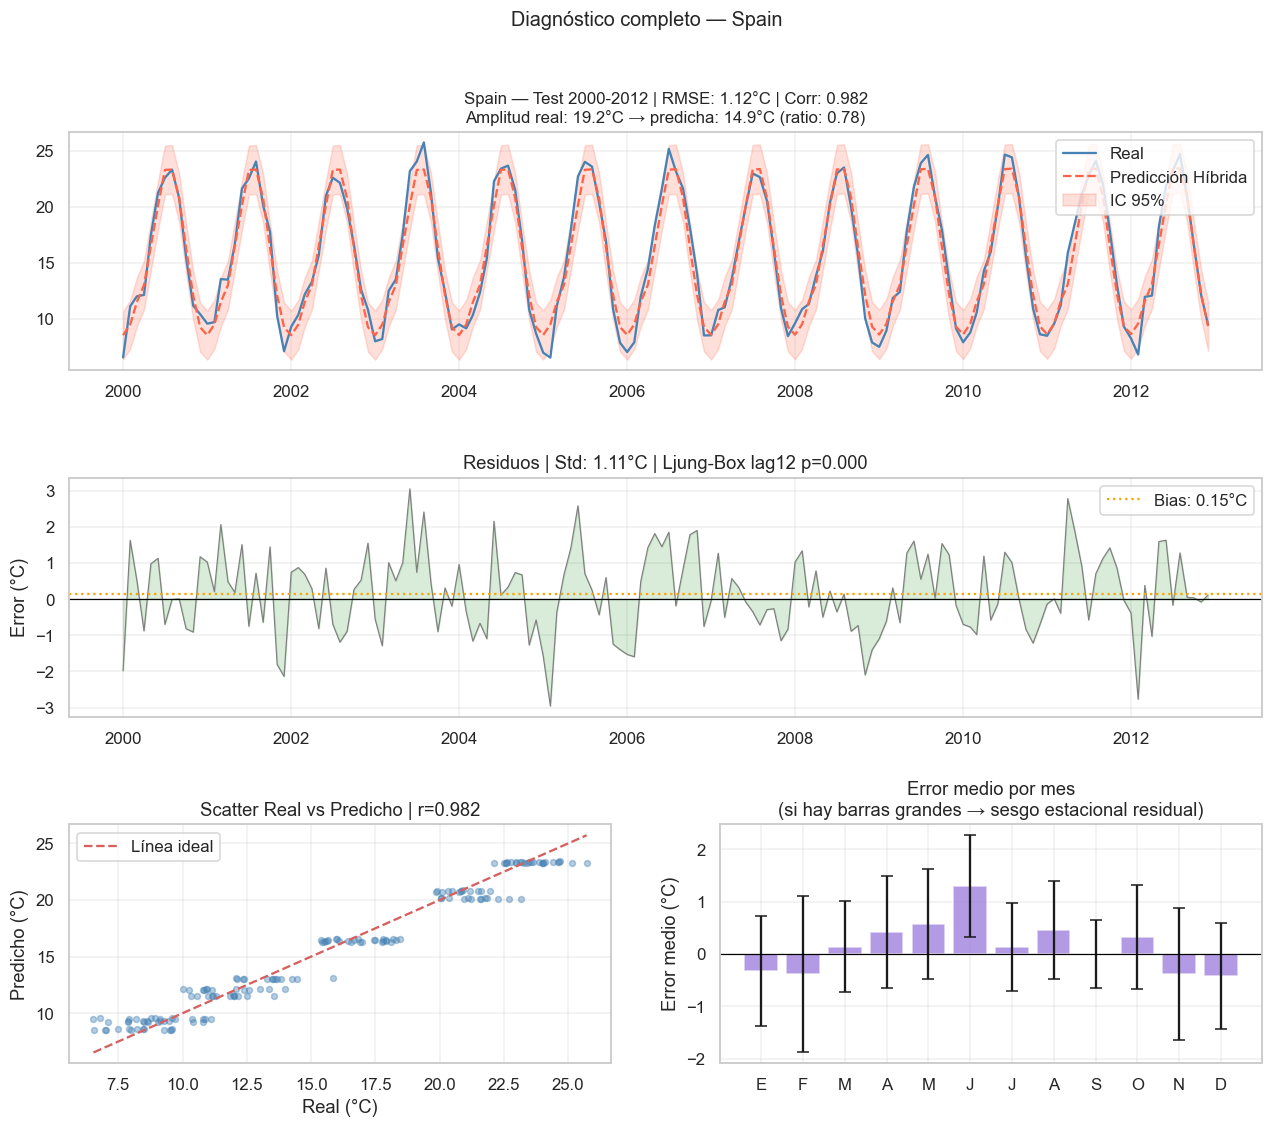

=== ESTADÍSTICAS FINALES — Spain ===
RMSE:          1.116°C
MAE:           0.908°C
Correlación:   0.9820
AmpRatio:      0.776  (>0.85 = sin aplanamiento significativo)
Bias medio:    0.153°C
Ljung-Box p12: 0.0000


In [25]:
# ============================================================
# CELDA 10 — Visualización detallada de validación por país
# Llama con cualquier país del dataset
# ============================================================

def plot_validation_full(country_name):
    safe = country_name.replace(' ', '_').replace('/', '_')
    path = os.path.join(MODEL_DIR, f'{safe}.joblib')
    
    if not os.path.exists(path):
        print(f'❌ Modelo no encontrado para {country_name}')
        return
    
    data = joblib.load(path)
    rmse_val = data.get('rmse_test', data.get('rmse'))
    dates = pd.to_datetime(data['test_dates'])
    real = np.array(data['test_real'])
    pred = np.array(data['test_pred'])
    ci_lo = np.array(data['ci_lower'])
    ci_hi = np.array(data['ci_upper'])
    resid = real - pred
    
    fig = plt.figure(figsize=(14, 11))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45)
    
    # 1. Real vs Predicho con IC
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(dates, real, label='Real', color='steelblue', lw=1.5)
    ax1.plot(dates, pred, label='Predicción Híbrida', color='tomato', lw=1.5, ls='--')
    ax1.fill_between(dates, ci_lo, ci_hi, alpha=0.2, color='tomato', label='IC 95%')
    amp_real = real.max() - real.min()
    amp_pred = pred.max() - pred.min()
    ax1.set_title(f'{country_name} — Test 2000-2012 | RMSE: {data["rmse"]:.2f}°C | Corr: {data["corr"]:.3f}\n'
                  f'Amplitud real: {amp_real:.1f}°C → predicha: {amp_pred:.1f}°C (ratio: {amp_pred/amp_real:.2f})',
                  fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Residuos en tiempo
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(dates, resid, color='gray', lw=0.8)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.fill_between(dates, 0, resid, color='green', alpha=0.15)
    ax2.axhline(resid.mean(), color='orange', ls=':', lw=1.5, label=f'Bias: {resid.mean():.2f}°C')
    ax2.set_title(f'Residuos | Std: {resid.std():.2f}°C | Ljung-Box lag12 p={data["resid_lb12_pval"]:.3f}')
    ax2.set_ylabel('Error (°C)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Scatter Real vs Predicho
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.scatter(real, pred, alpha=0.4, s=15, color='steelblue')
    lims = [min(real.min(), pred.min()), max(real.max(), pred.max())]
    ax3.plot(lims, lims, 'r--', lw=1.5, label='Línea ideal')
    ax3.set_xlabel('Real (°C)')
    ax3.set_ylabel('Predicho (°C)')
    ax3.set_title(f'Scatter Real vs Predicho | r={data["corr"]:.3f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Error por mes del año (¿hay sesgo estacional?)
    ax4 = fig.add_subplot(gs[2, 1])
    df_resid = pd.DataFrame({'month': dates.month, 'resid': resid})
    monthly_err = df_resid.groupby('month')['resid'].agg(['mean', 'std']).reset_index()
    ax4.bar(monthly_err['month'], monthly_err['mean'], 
            yerr=monthly_err['std'], color='mediumpurple', alpha=0.7, capsize=4)
    ax4.axhline(0, color='black', lw=0.8)
    ax4.set_xticks(range(1, 13))
    ax4.set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'])
    ax4.set_title('Error medio por mes\n(si hay barras grandes → sesgo estacional residual)')
    ax4.set_ylabel('Error medio (°C)')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Diagnóstico completo — {country_name}', fontsize=13)
    plt.show()
    
    print(f'=== ESTADÍSTICAS FINALES — {country_name} ===')
    print(f'RMSE:          {data["rmse"]:.3f}°C')
    print(f'MAE:           {data["mae"]:.3f}°C')
    print(f'Correlación:   {data["corr"]:.4f}')
    print(f'AmpRatio:      {data["amp_ratio"]:.3f}  (>0.85 = sin aplanamiento significativo)')
    print(f'Bias medio:    {resid.mean():.3f}°C')
    print(f'Ljung-Box p12: {data["resid_lb12_pval"]:.4f}')


# --- Ejecutar ---
plot_validation_full('Spain')

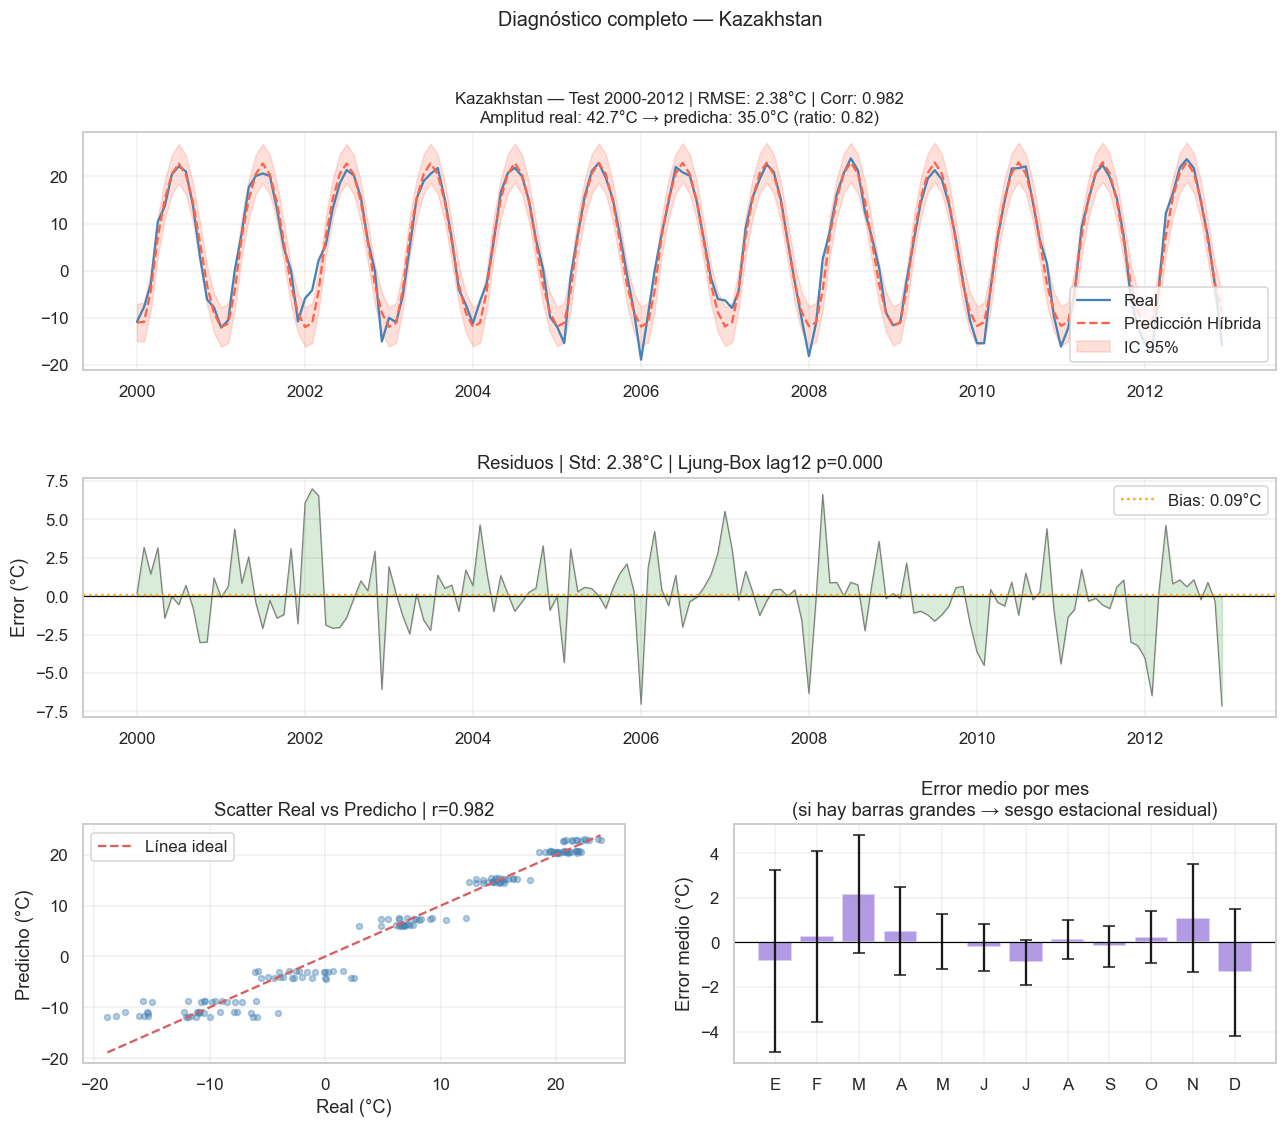

=== ESTADÍSTICAS FINALES — Kazakhstan ===
RMSE:          2.377°C
MAE:           1.650°C
Correlación:   0.9822
AmpRatio:      0.820  (>0.85 = sin aplanamiento significativo)
Bias medio:    0.086°C
Ljung-Box p12: 0.0000


In [26]:
# ============================================================
# CELDA 11 — Comparar país difícil (Kazakhstan) vs país fácil (Spain)
# ============================================================
plot_validation_full('Kazakhstan')

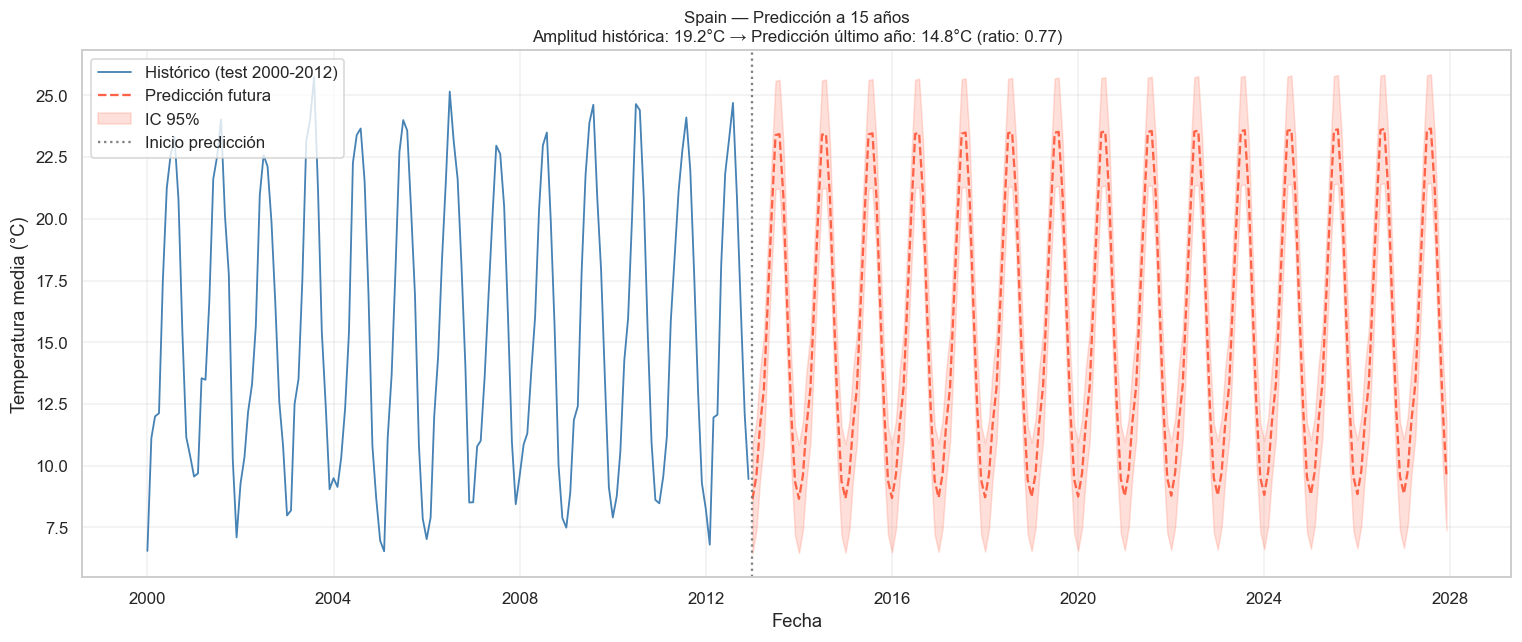

Amplitud estacional histórica:           19.19°C
Amplitud estacional (último año pred):   14.78°C
Ratio de preservación de estacionalidad: 0.770  (ideal: ~1.0)


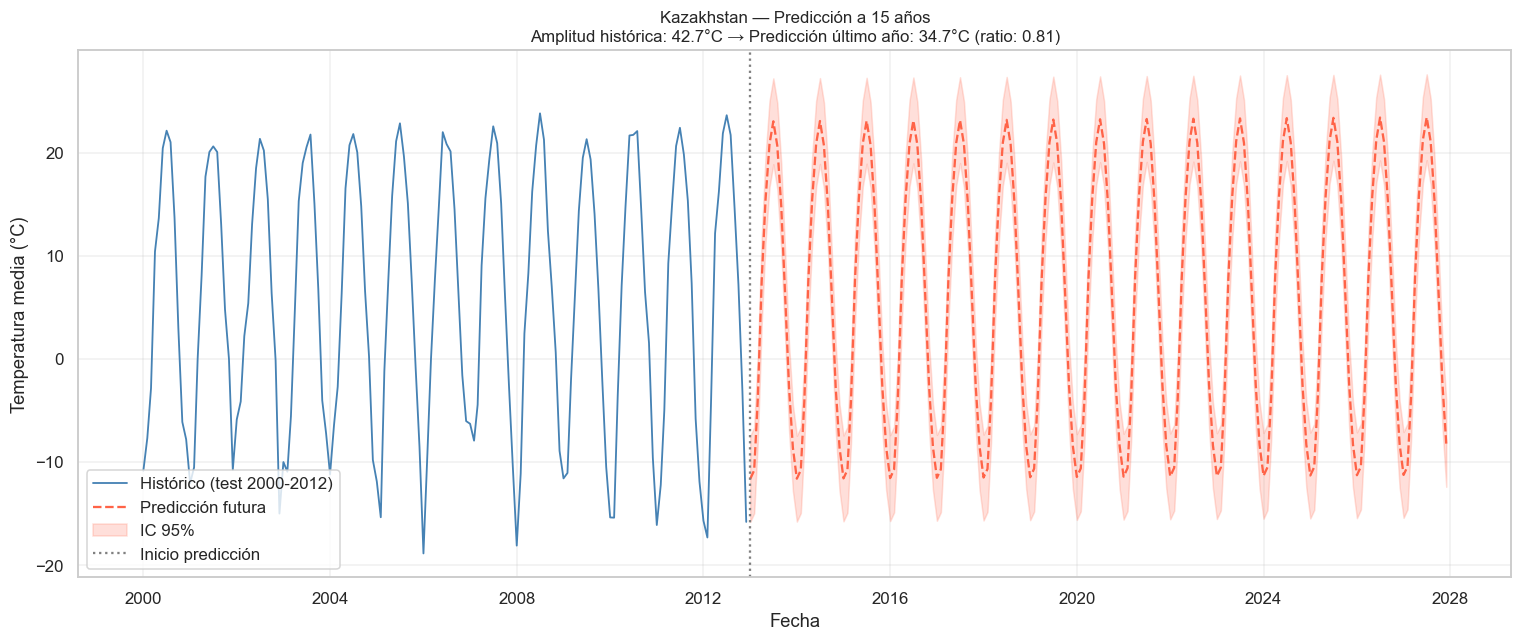

Amplitud estacional histórica:           42.70°C
Amplitud estacional (último año pred):   34.71°C
Ratio de preservación de estacionalidad: 0.813  (ideal: ~1.0)


In [27]:
# ============================================================
# CELDA 12 — Predicción futura con intervalos de confianza
# Aquí se ve la mejora clave: la curva anual NO se aplana
# ============================================================

def plot_future_forecast(country_name, years_ahead=15):
    safe = country_name.replace(' ', '_').replace('/', '_')
    path = os.path.join(MODEL_DIR, f'{safe}.joblib')
    
    if not os.path.exists(path):
        print(f'❌ Modelo no encontrado para {country_name}')
        return
    
    data = joblib.load(path)
    reg = data['reg']
    model_arima = data['model_arima']
    n_periods = years_ahead * 12
    n_train = data['n_train']
    
    # Componente determinista futura
    t_future_arr = np.arange(n_train, n_train + len(data['test_dates']) + n_periods)
    future_dates_full = pd.date_range(
        start=data['test_dates'][0], periods=len(data['test_dates']) + n_periods, freq='MS'
    )
    months_future = future_dates_full.month
    X_future_full = np.column_stack([
        t_future_arr,
        *[(months_future == m).astype(int) for m in range(1, 12)]
    ])
    pred_det_full = reg.predict(X_future_full)
    
    # Componente ARIMA futura
    pred_arima_full, ci_arima_full = model_arima.predict(
        n_periods=len(data['test_dates']) + n_periods, return_conf_int=True
    )
    
    pred_full = pred_det_full + pred_arima_full
    ci_lo_full = pred_det_full + ci_arima_full[:, 0]
    ci_hi_full = pred_det_full + ci_arima_full[:, 1]
    
    # Solo mostramos la parte futura (después del test)
    n_test = len(data['test_dates'])
    future_only_dates = future_dates_full[n_test:]
    pred_future_only = pred_full[n_test:]
    ci_lo_only = ci_lo_full[n_test:]
    ci_hi_only = ci_hi_full[n_test:]
    
    # Comparar amplitud
    amp_hist = np.array(data['test_real']).max() - np.array(data['test_real']).min()
    amp_pred_last12 = pred_future_only[-12:].max() - pred_future_only[-12:].min()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Histórico reciente
    test_dates = pd.to_datetime(data['test_dates'])
    ax.plot(test_dates, data['test_real'], color='steelblue', lw=1.2, label='Histórico (test 2000-2012)')
    
    # Predicción futura
    ax.plot(future_only_dates, pred_future_only, color='tomato', lw=1.5, ls='--', label='Predicción futura')
    ax.fill_between(future_only_dates, ci_lo_only, ci_hi_only, alpha=0.2, color='tomato', label='IC 95%')
    
    ax.axvline(future_only_dates[0], color='gray', ls=':', lw=1.5, label='Inicio predicción')
    
    ax.set_title(f'{country_name} — Predicción a {years_ahead} años\n'
                 f'Amplitud histórica: {amp_hist:.1f}°C → Predicción último año: {amp_pred_last12:.1f}°C '
                 f'(ratio: {amp_pred_last12/amp_hist:.2f})',
                 fontsize=11)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Temperatura media (°C)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f'Amplitud estacional histórica:           {amp_hist:.2f}°C')
    print(f'Amplitud estacional (último año pred):   {amp_pred_last12:.2f}°C')
    print(f'Ratio de preservación de estacionalidad: {amp_pred_last12/amp_hist:.3f}  (ideal: ~1.0)')


plot_future_forecast('Spain', years_ahead=15)
plot_future_forecast('Kazakhstan', years_ahead=15)

=== DISTRIBUCIÓN DE CALIDAD DEL MODELO ===


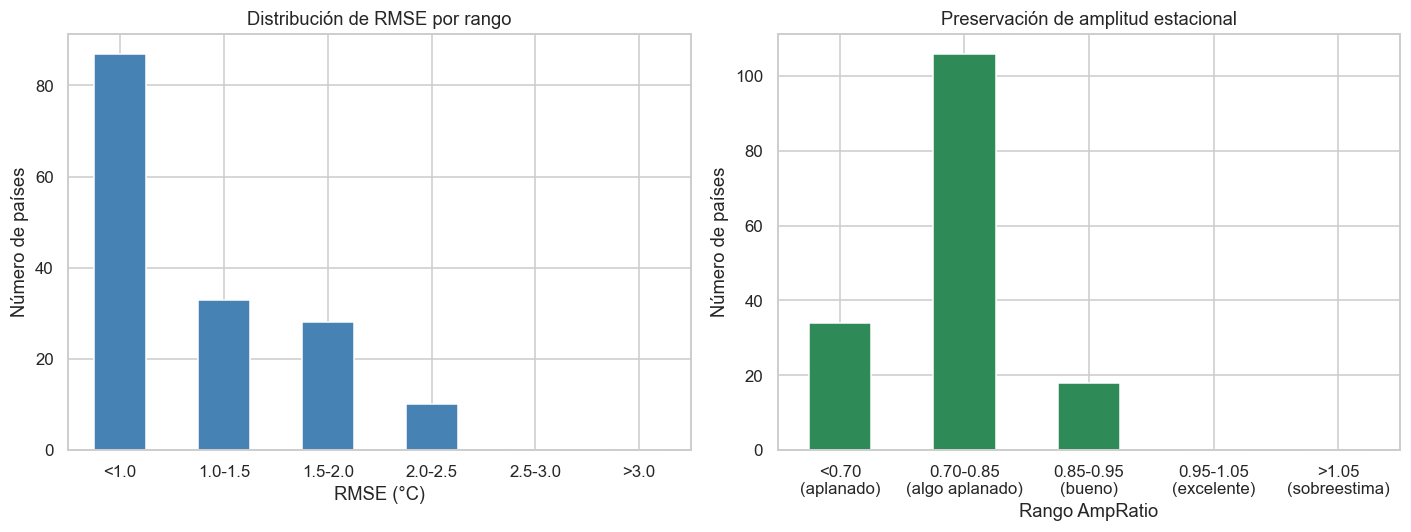

Países con RMSE < 2.0°C:              94%
Países con AmpRatio ∈ [0.85, 1.15]:   11%


In [28]:
# ============================================================
# CELDA 13 — Mapa de calidad del modelo por región
# ============================================================
print('=== DISTRIBUCIÓN DE CALIDAD DEL MODELO ===')

bins_rmse = [0, 1.0, 1.5, 2.0, 2.5, 3.0, float('inf')]
labels_rmse = ['<1.0', '1.0-1.5', '1.5-2.0', '2.0-2.5', '2.5-3.0', '>3.0']
metrics_df['RMSE_bin'] = pd.cut(metrics_df['RMSE'], bins=bins_rmse, labels=labels_rmse)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rmse_counts = metrics_df['RMSE_bin'].value_counts().reindex(labels_rmse)
rmse_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de RMSE por rango')
axes[0].set_xlabel('RMSE (°C)')
axes[0].set_ylabel('Número de países')
axes[0].tick_params(axis='x', rotation=0)

metrics_df['AmpRatio_bin'] = pd.cut(
    metrics_df['AmpRatio'].clip(0, 1.5),
    bins=[0, 0.7, 0.85, 0.95, 1.05, 1.5],
    labels=['<0.70\n(aplanado)', '0.70-0.85\n(algo aplanado)', '0.85-0.95\n(bueno)', '0.95-1.05\n(excelente)', '>1.05\n(sobreestima)']
)
metrics_df['AmpRatio_bin'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Preservación de amplitud estacional')
axes[1].set_xlabel('Rango AmpRatio')
axes[1].set_ylabel('Número de países')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

pct_good_rmse = (metrics_df['RMSE'] < 2.0).mean()
pct_good_amp = (metrics_df['AmpRatio'].between(0.85, 1.15)).mean()
print(f'Países con RMSE < 2.0°C:              {pct_good_rmse:.0%}')
print(f'Países con AmpRatio ∈ [0.85, 1.15]:   {pct_good_amp:.0%}')

In [29]:
# ============================================================
# CELDA — Reentrenamiento final con todos los datos
# ============================================================

def retrain_final_model(country_name, df_country):
    """
    Reentrena el modelo híbrido con el 100% de los datos.
    Usar solo después de validar las métricas en test.
    """
    try:
        df_c = df_country.copy()
        df_c['date'] = pd.to_datetime(df_c[['year', 'month']].assign(day=1))
        df_c.set_index('date', inplace=True)
        df_c.sort_index(inplace=True)
        df_c = df_c[df_c.index >= '1950-01-01']
        df_c = df_c[~df_c.index.duplicated(keep='first')]
        full_range = pd.date_range(start=df_c.index.min(), end=df_c.index.max(), freq='MS')
        df_c = df_c.reindex(full_range)
        df_c['AvTemp'] = df_c['AvTemp'].interpolate(method='linear', limit_area='inside')
        df_c.dropna(subset=['AvTemp'], inplace=True)
        if len(df_c) < 48: return None

        series = df_c['AvTemp']  # 100% de los datos

        # Tendencia + dummies sobre todos los datos
        t = np.arange(len(series))
        m = series.index.month
        X = np.column_stack([t, *[(m == mo).astype(int) for mo in range(1, 12)]])
        reg = LinearRegression().fit(X, series.values)
        resid = series.values - reg.predict(X)

        # ARIMA sobre residuo completo
        model_arima = auto_arima(
            resid, m=1, seasonal=False,
            max_p=3, max_q=3, max_d=2,
            stepwise=True, suppress_warnings=True, error_action='ignore'
        )

        # Guardar — sobreescribe el modelo de validación
        safe = country_name.replace(' ', '_').replace('/', '_')
        path = os.path.join(MODEL_DIR, f'{safe}.joblib')

        # Cargar métricas del modelo de validación (las conservamos)
        old = joblib.load(path) if os.path.exists(path) else {}

        joblib.dump({
            **old,                          # conserva rmse, mae, corr del test
            'reg': reg,                     # sobreescribe con modelo completo
            'model_arima': model_arima,
            'arima_order': model_arima.order,
            'n_train': len(series),         # ahora es el total
            'series_end': series.index[-1],
            'retrained_full': True,
        }, path)

        return country_name

    except Exception as e:
        print(f'❌ {country_name}: {e}')
        return None


print('🔁 Reentrenando con datos completos...')
grouped = df.groupby('country')

final_results = Parallel(n_jobs=-1, backend='loky', verbose=0)(
    delayed(retrain_final_model)(name, group)
    for name, group in tqdm(grouped, total=len(grouped), desc='Reentrenando')
)

ok = [r for r in final_results if r is not None]
print(f'✅ {len(ok)} modelos reentrenados con datos completos')

🔁 Reentrenando con datos completos...


Reentrenando: 100%|██████████| 158/158 [00:30<00:00,  5.21it/s]


✅ 158 modelos reentrenados con datos completos


* Para el 94% de los países con buen RMSE, puedes confiar en la tendencia proyectada.
* Para el 11% con buen AmpRatio (probablemente países con estacionalidad muy marcada y estable), puedes confiar también en la intensidad estacional.
* Para el resto (buen RMSE, mal AmpRatio), usa las predicciones solo como referencia de tendencia, sabiendo que los extremos estarán suavizados.